# Prophet — Prognose mit Konfidenz-/Vorhersageintervallen

Dieses Notebook erzeugt für **eine Station** eine Prophet-Prognose ab **01.09.2016** und gibt die
**Vorhersageintervalle** (Prophets `yhat_lower` / `yhat_upper`) für die Horizonte **8, 24, 48 und 72 Stunden** aus.

**Was zeigt das Intervall?** Prophet liefert um die Punktprognose `yhat` ein Unsicherheitsband. Es speist sich
aus (a) der Trend-Unsicherheit (mögliche zukünftige Trendänderungen an den Changepoints) und (b) dem
Beobachtungsrauschen. Standardbreite ist **80 %** (`interval_width=0.80`) — d. h. rund 80 % der echten Werte
sollten *im Mittel über viele Fenster* im Band liegen. Da wir auf `log1p(PM2.5)` modellieren und zurück­transformieren,
ist das Band **asymmetrisch** (unten enger, oben weiter) — passend zu rechtsschiefem Feinstaub.

> Hinweis: Die Wetter-Regressoren werden als *Perfect-Prognosis* (tatsächliche Zukunftswerte) übergeben — konsistent
> zum Modellvergleich. Auf `MIT_REGRESSOREN = False` stellen für eine reine Trend/Saison-Prognose.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, logging
import matplotlib.pyplot as plt
from pathlib import Path
from prophet import Prophet
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

# ---------------- Konfiguration (frei anpassbar) ----------------
STATION          = "Dongsi"                 # eine der 12 Stationen
PROGNOSE_START   = pd.Timestamp("2016-09-01")
HORIZONTE        = [8, 24, 48, 72]          # Stunden
INTERVALL_BREITE = 0.80                     # 0.80 = 80 %-Intervall (z. B. 0.95 fuer 95 %)
LOG              = True                     # log1p-Transformation der Zielgroesse
MIT_REGRESSOREN  = True                     # Wetter als Perfect-Prognosis mitfuehren

PREP = Path("../data/prepared_chronos/behandelt")
WETTER_REGRESSOREN = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos"]
REG = WETTER_REGRESSOREN if MIT_REGRESSOREN else []
print(f"Station {STATION} | Start {PROGNOSE_START.date()} | {int(INTERVALL_BREITE*100)}%-Intervall | "
      f"Regressoren: {'ja' if MIT_REGRESSOREN else 'nein'}")

Importing plotly failed. Interactive plots will not work.


Station Dongsi | Start 2016-09-01 | 80%-Intervall | Regressoren: ja


## 1. Daten laden und auf ein lückenloses Stundenraster bringen

In [2]:
def regularize(df, spalten, freq="h"):
    d = df.set_index("ds").sort_index()
    d = d.reindex(pd.date_range(d.index.min(), d.index.max(), freq=freq))
    for c in spalten:
        d[c] = d[c].interpolate(limit_direction="both")
    d.index.name = "ds"
    return d.reset_index()

gesamt = pd.read_csv(PREP / f"chronos_{STATION}.csv", parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
gesamt = regularize(gesamt, ["y"] + WETTER_REGRESSOREN)

# Training = alles VOR dem Prognosestart; Testfenster = 72 h ab Start (inkl. +72 h fuer die Tabelle)
train = gesamt[gesamt["ds"] < PROGNOSE_START].copy()
test  = gesamt[(gesamt["ds"] >= PROGNOSE_START) &
               (gesamt["ds"] <= PROGNOSE_START + pd.Timedelta(hours=max(HORIZONTE)))].reset_index(drop=True)
print(f"Training: {len(train)} Stunden (bis {train['ds'].max()}) | Testfenster: {len(test)} Stunden")

Training: 30720 Stunden (bis 2016-08-31 23:00:00) | Testfenster: 73 Stunden


## 2. Prophet trainieren und Prognose inkl. Intervall erzeugen

In [3]:
train_c = train[["ds", "y"] + REG].copy()
if LOG:
    train_c["y"] = np.log1p(train_c["y"])

m = Prophet(interval_width=INTERVALL_BREITE,
            yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
m.add_country_holidays(country_name="CN")
for r in REG:
    m.add_regressor(r)
m.fit(train_c)

forecast = m.predict(test[["ds"] + REG])

# Ruecktransformation (log1p -> µg/m³) und Abschneiden bei 0
zurueck = (lambda a: np.expm1(a)) if LOG else (lambda a: a)
for c in ["yhat", "yhat_lower", "yhat_upper"]:
    forecast[c] = np.clip(zurueck(forecast[c]), 0, None)

ergebnis = test[["ds", "y"]].merge(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
ergebnis["lead_h"] = ((ergebnis["ds"] - PROGNOSE_START).dt.total_seconds() // 3600).astype(int)
print("Prognose erzeugt.")

00:03:58 - cmdstanpy - INFO - Chain [1] start processing
00:04:18 - cmdstanpy - INFO - Chain [1] done processing


Prognose erzeugt.


## 3. Intervalle an den Horizonten 8 / 24 / 48 / 72 h

In [4]:
q_low  = round((1 - INTERVALL_BREITE) / 2 * 100)
q_high = round((1 + INTERVALL_BREITE) / 2 * 100)

tabelle = ergebnis[ergebnis["lead_h"].isin(HORIZONTE)].copy()
tabelle["Ist_im_Intervall"] = (tabelle["y"] >= tabelle["yhat_lower"]) & (tabelle["y"] <= tabelle["yhat_upper"])
tabelle["Intervallbreite"] = tabelle["yhat_upper"] - tabelle["yhat_lower"]

anzeige = tabelle[["lead_h", "ds", "y", "yhat_lower", "yhat", "yhat_upper", "Intervallbreite", "Ist_im_Intervall"]]
anzeige = anzeige.rename(columns={"lead_h": "Horizont [h]", "ds": "Zeitpunkt", "y": "Ist (µg/m³)",
    "yhat_lower": f"Unter (P{q_low})", "yhat": "Prognose", "yhat_upper": f"Ober (P{q_high})"})
print(f"{STATION} — {int(INTERVALL_BREITE*100)}%-Vorhersageintervall ab {PROGNOSE_START.date()}:\n")
print(anzeige.round(1).to_string(index=False))

# Als CSV speichern (fuer Deck/Bericht)
AUSGABE_CSV = Path(f"../data/prophet_ki_{STATION}_{PROGNOSE_START.date()}.csv")
anzeige.round(2).to_csv(AUSGABE_CSV, index=False)
print(f"\nGespeichert: {AUSGABE_CSV}")

Dongsi — 80%-Vorhersageintervall ab 2016-09-01:

 Horizont [h]           Zeitpunkt  Ist (µg/m³)  Unter (P10)  Prognose  Ober (P90)  Intervallbreite  Ist_im_Intervall
            8 2016-09-01 08:00:00          4.0          2.8       8.7        23.1             20.3              True
           24 2016-09-02 00:00:00         12.0         12.9      32.9        80.2             67.3             False
           48 2016-09-03 00:00:00         10.0         16.1      43.0       105.2             89.1             False
           72 2016-09-04 00:00:00         50.0         22.0      55.4       140.6            118.7              True

Gespeichert: ..\data\prophet_ki_Dongsi_2016-09-01.csv


## 4. Plot: Prognose mit Intervallband, echten Werten und Horizont-Markern

Plot gespeichert: ..\grafiken\prophet_ki_Dongsi_2016-09-01.png


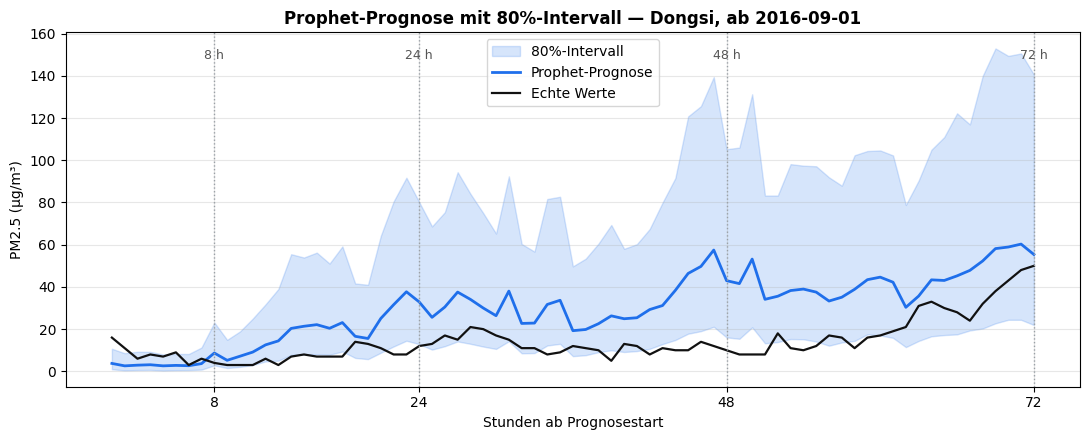

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = ergebnis["lead_h"]
ax.fill_between(x, ergebnis["yhat_lower"], ergebnis["yhat_upper"], color="#1f6feb", alpha=0.18,
                label=f"{int(INTERVALL_BREITE*100)}%-Intervall")
ax.plot(x, ergebnis["yhat"], color="#1f6feb", lw=2, label="Prophet-Prognose")
ax.plot(x, ergebnis["y"], color="#111111", lw=1.6, label="Echte Werte")
for h in HORIZONTE:
    ax.axvline(h, color="#9aa0a6", ls=":", lw=1)
    zeile = tabelle[tabelle["lead_h"] == h]
    if not zeile.empty:
        yv = float(zeile["yhat"].iloc[0])
        ax.annotate(f"{h} h", xy=(h, yv), xytext=(h, ax.get_ylim()[1]*0.92),
                    ha="center", fontsize=9, color="#555")
ax.set_xlabel("Stunden ab Prognosestart"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title(f"Prophet-Prognose mit {int(INTERVALL_BREITE*100)}%-Intervall — {STATION}, ab {PROGNOSE_START.date()}",
             fontweight="bold")
ax.set_xticks(HORIZONTE); ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout()
AUSGABE_PNG = Path(f"../grafiken/prophet_ki_{STATION}_{PROGNOSE_START.date()}.png")
fig.savefig(AUSGABE_PNG, dpi=130, bbox_inches="tight")
print(f"Plot gespeichert: {AUSGABE_PNG}")
plt.show()

## 5. Alle 12 Stationen: Intervalle je Horizont

Wiederholt die Prognose für **jede Station** und sammelt die Intervalle in einer Tabelle. Ein Prophet-Fit pro Station (~15–20 s) → **rechne mit ~3–4 min** für alle 12.

In [6]:
ALLE_STATIONEN = sorted(p.name.replace("chronos_", "").replace(".csv", "") for p in PREP.glob("chronos_*.csv"))

def prophet_intervalle(station):
    """Prophet-Fit fuer eine Station; Rueckgabe der Intervalle an den HORIZONTEN (long-form)."""
    g = regularize(pd.read_csv(PREP / f"chronos_{station}.csv", parse_dates=["ds"]).sort_values("ds"),
                   ["y"] + WETTER_REGRESSOREN)
    tr = g[g["ds"] < PROGNOSE_START].copy()
    te = g[(g["ds"] >= PROGNOSE_START) &
           (g["ds"] <= PROGNOSE_START + pd.Timedelta(hours=max(HORIZONTE)))].reset_index(drop=True)
    trc = tr[["ds", "y"] + REG].copy()
    if LOG:
        trc["y"] = np.log1p(trc["y"])
    mm = Prophet(interval_width=INTERVALL_BREITE,
                 yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
    mm.add_country_holidays(country_name="CN")
    for r in REG:
        mm.add_regressor(r)
    mm.fit(trc)
    fcc = mm.predict(te[["ds"] + REG])
    zurueck = (lambda a: np.expm1(a)) if LOG else (lambda a: a)
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        fcc[c] = np.clip(zurueck(fcc[c]), 0, None)
    r = te[["ds", "y"]].merge(fcc[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    r["lead_h"] = ((r["ds"] - PROGNOSE_START).dt.total_seconds() // 3600).astype(int)
    r.insert(0, "Station", station)
    return r   # volles Fenster (alle Stunden 0..max(HORIZONTE))

teile = []
for st in ALLE_STATIONEN:
    teile.append(prophet_intervalle(st))
    print(f"{st} fertig.")

tabelle_alle_full = pd.concat(teile, ignore_index=True)                       # volles Fenster je Station
tabelle_alle = tabelle_alle_full[tabelle_alle_full["lead_h"].isin(HORIZONTE)].copy()  # nur die 4 Horizont-Punkte
tabelle_alle["im_Intervall"] = ((tabelle_alle["y"] >= tabelle_alle["yhat_lower"]) &
                                (tabelle_alle["y"] <= tabelle_alle["yhat_upper"]))

CSV_ALLE = Path(f"../data/prophet_ki_alle_stationen_{PROGNOSE_START.date()}.csv")
tabelle_alle.round(2).to_csv(CSV_ALLE, index=False)
print(f"\nGespeichert: {CSV_ALLE}  ({len(tabelle_alle)} Zeilen = "
      f"{len(ALLE_STATIONEN)} Stationen x {len(HORIZONTE)} Horizonte)")

00:04:24 - cmdstanpy - INFO - Chain [1] start processing
00:04:35 - cmdstanpy - INFO - Chain [1] done processing


Aotizhongxin fertig.


00:04:40 - cmdstanpy - INFO - Chain [1] start processing
00:04:54 - cmdstanpy - INFO - Chain [1] done processing


Changping fertig.


00:04:59 - cmdstanpy - INFO - Chain [1] start processing
00:05:12 - cmdstanpy - INFO - Chain [1] done processing


...

Tiantan fertig.


00:07:47 - cmdstanpy - INFO - Chain [1] start processing
00:07:57 - cmdstanpy - INFO - Chain [1] done processing


Wanliu fertig.


00:08:03 - cmdstanpy - INFO - Chain [1] start processing
00:08:29 - cmdstanpy - INFO - Chain [1] done processing


Wanshouxigong fertig.

Gespeichert: ..\data\prophet_ki_alle_stationen_2016-09-01.csv  (48 Zeilen = 12 Stationen x 4 Horizonte)


In [7]:
# Kompakte Ansicht: "Prognose [Unter-Ober]" je Station und Horizont
tabelle_alle["Intervall"] = tabelle_alle.apply(
    lambda r: f"{r['yhat']:.0f} [{r['yhat_lower']:.0f}-{r['yhat_upper']:.0f}]", axis=1)
pivot = tabelle_alle.pivot(index="Station", columns="lead_h", values="Intervall")
pivot.columns = [f"{h} h" for h in pivot.columns]
print(f"Prognose [Unter-Ober] in µg/m³, {int(INTERVALL_BREITE*100)}%-Intervall, ab {PROGNOSE_START.date()}:\n")
print(pivot.to_string())

print("\nAbdeckung (Anteil Stationen mit Ist-Wert im Band) je Horizont:")
print((tabelle_alle.groupby("lead_h")["im_Intervall"].mean() * 100).round(0).astype(int).astype(str).add(" %").to_string())

Prognose [Unter-Ober] in µg/m³, 80%-Intervall, ab 2016-09-01:

                    8 h        24 h         48 h         72 h
Station                                                      
Aotizhongxin   8 [2-19]  26 [10-65]   36 [14-86]  47 [19-115]
Changping      4 [1-10]   19 [8-48]    24 [8-61]    25 [9-64]
Dingling        2 [0-8]   17 [6-44]    21 [7-57]    23 [8-62]
Dongsi         9 [3-23]  33 [12-83]  43 [16-100]  55 [22-142]
Guanyuan       9 [3-24]  29 [11-72]   39 [16-96]  49 [19-119]
Gucheng        5 [2-14]  31 [12-73]   36 [15-84]  53 [23-127]
Huairou        5 [2-16]   14 [5-35]    26 [9-66]   37 [13-99]
Nongzhanguan   8 [3-21]  29 [11-71]   37 [13-86]  49 [22-129]
Shunyi         8 [3-20]   21 [8-56]   37 [14-90]  67 [27-183]
Tiantan        9 [3-23]  29 [12-72]  38 [15-100]  49 [20-115]
Wanliu         8 [3-21]   24 [9-63]   31 [12-74]  48 [18-121]
Wanshouxigong  9 [3-24]  32 [12-79]  44 [17-106]  54 [22-138]

Abdeckung (Anteil Stationen mit Ist-Wert im Band) je Horizont:
lead_

Plot gespeichert: ..\grafiken\prophet_ki_alle_stationen_2016-09-01.png


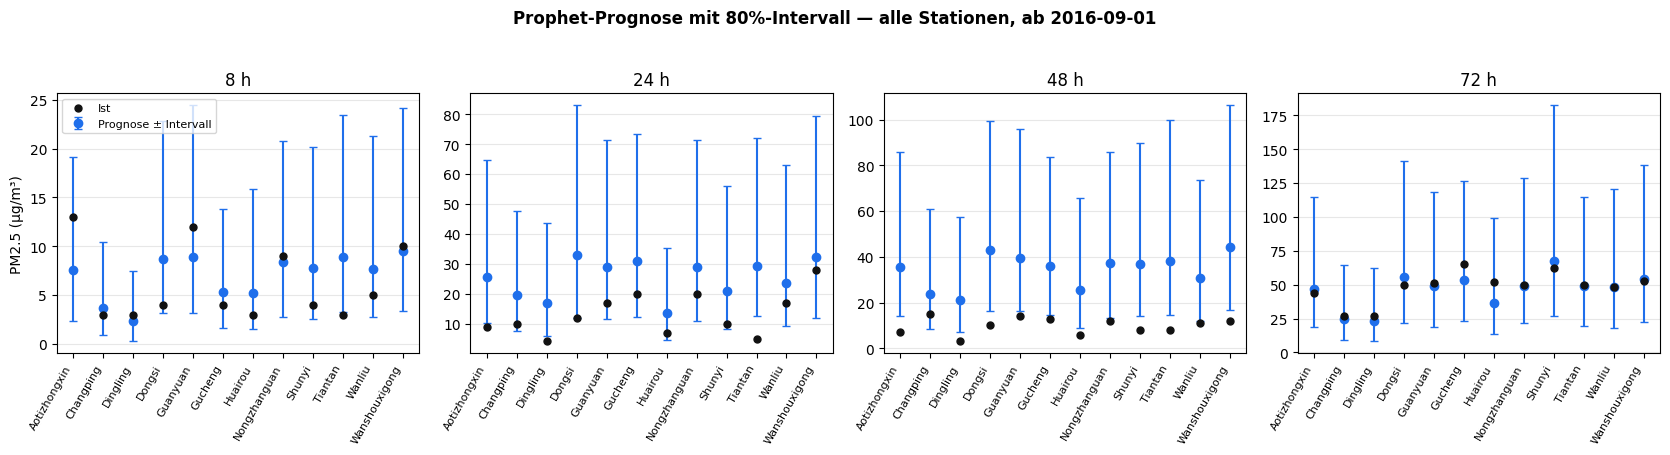

In [8]:
fig, axes = plt.subplots(1, len(HORIZONTE), figsize=(4.2 * len(HORIZONTE), 4.6), sharey=False)
for ax, h in zip(axes, HORIZONTE):
    w = tabelle_alle[tabelle_alle["lead_h"] == h].reset_index(drop=True)
    x = np.arange(len(w))
    ax.errorbar(x, w["yhat"], yerr=[w["yhat"] - w["yhat_lower"], w["yhat_upper"] - w["yhat"]],
                fmt="o", color="#1f6feb", capsize=3, label="Prognose ± Intervall")
    ax.scatter(x, w["y"], color="#111111", zorder=5, s=25, label="Ist")
    ax.set_xticks(x); ax.set_xticklabels(w["Station"], rotation=60, ha="right", fontsize=8)
    ax.set_title(f"{h} h"); ax.grid(alpha=0.3, axis="y")
axes[0].set_ylabel("PM2.5 (µg/m³)"); axes[0].legend(fontsize=8, loc="upper left")
plt.suptitle(f"Prophet-Prognose mit {int(INTERVALL_BREITE*100)}%-Intervall — alle Stationen, ab {PROGNOSE_START.date()}",
             fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
AUSGABE_PNG_ALLE = Path(f"../grafiken/prophet_ki_alle_stationen_{PROGNOSE_START.date()}.png")
fig.savefig(AUSGABE_PNG_ALLE, dpi=130, bbox_inches="tight")
print(f"Plot gespeichert: {AUSGABE_PNG_ALLE}")
plt.show()

### 5b. Kumulativer Fehler über den Horizont-Zeitraum (0–8 / 0–24 / 0–48 / 0–72 h)

Statt der vier einzelnen Stundenpunkte hier der **mittlere Fehler über den gesamten Zeitraum** bis zum jeweiligen Horizont (alle Stunden, alle Stationen). Das glättet Zufallstreffer einzelner Zeitpunkte heraus und zeigt den erwarteten **monotonen Anstieg** des Fehlers mit dem Horizont.

Mittlerer Fehler über den Horizont-Zeitraum (alle Stunden, alle Stationen):

Zeitraum  MAE (µg/m³)  RMSE (µg/m³)  Abdeckung %
   0-8 h          5.0           6.8           65
  0-24 h          7.6           9.5           63
  0-48 h         10.8          13.5           60
  0-72 h         12.7          15.4           61


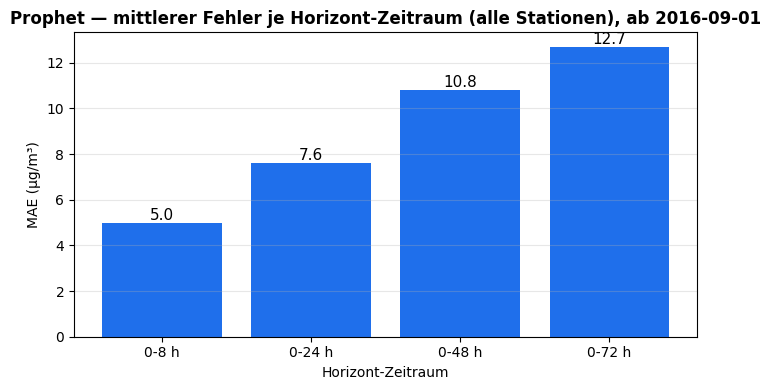

In [9]:
zeilen = []
for b in HORIZONTE:
    w = tabelle_alle_full[tabelle_alle_full["lead_h"] <= b]
    mae  = (w["yhat"] - w["y"]).abs().mean()
    rmse = np.sqrt(((w["yhat"] - w["y"]) ** 2).mean())
    cov  = ((w["y"] >= w["yhat_lower"]) & (w["y"] <= w["yhat_upper"])).mean() * 100
    zeilen.append({"Zeitraum": f"0-{b} h", "MAE (µg/m³)": round(mae, 1),
                   "RMSE (µg/m³)": round(rmse, 1), "Abdeckung %": int(round(cov))})
kumulativ = pd.DataFrame(zeilen)
print("Mittlerer Fehler über den Horizont-Zeitraum (alle Stunden, alle Stationen):\n")
print(kumulativ.to_string(index=False))
kumulativ.to_csv(Path(f"../data/prophet_ki_kumulativ_{PROGNOSE_START.date()}.csv"), index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(kumulativ["Zeitraum"], kumulativ["MAE (µg/m³)"], color="#1f6feb")
for i, v in enumerate(kumulativ["MAE (µg/m³)"]):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("MAE (µg/m³)"); ax.set_xlabel("Horizont-Zeitraum")
ax.set_title(f"Prophet — mittlerer Fehler je Horizont-Zeitraum (alle Stationen), ab {PROGNOSE_START.date()}",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(Path(f"../grafiken/prophet_ki_kumulativ_{PROGNOSE_START.date()}.png"), dpi=130, bbox_inches="tight")
plt.show()

## Hinweise zur Interpretation

- Das Band ist **kein** „Konfidenzintervall des Mittelwerts", sondern ein **Vorhersageintervall** für den
  tatsächlichen PM2.5-Wert. Es wird mit dem Horizont breiter (mehr Unsicherheit weiter in der Zukunft).
- Die **Abdeckung an einem einzelnen Fenster** ist Zufall — ob z. B. 80 % der Werte im Band liegen, gilt erst
  im Mittel über *viele* Startzeitpunkte. Für eine echte Kalibrierungsprüfung müsste man das Band über den
  Rolling-Window-Backtest (Notebook 05) auswerten.
- `INTERVALL_BREITE = 0.95` liefert ein breiteres 95 %-Band; `MIT_REGRESSOREN = False` zeigt die reine
  Trend/Saison-Unsicherheit ohne Wettereinfluss.